# Baseline BFP-PE: FP-Acc / INT-MAC Power and Area

This notebook plots hierarchical synthesis results for the Baseline BFP-PE. Each data format has two stacked bars (Area and Power), with FP-Acc and INT-MAC contributions shown in their measured units.

- **Area**: component total cell area from `area_h.rpt` (library area units).
- **Power**: component total power from `power_h.rpt` (mW); total power includes switching, internal, and leakage power.
- The current points are **BFP4–BFP7, G16**. To add formats later, append one dictionary per component to `records` in the next cell.

The chart intentionally excludes BFP-PE top-level glue logic, so it compares only FP-Acc and INT-MAC. The bar labels show each component's percentage of the complete BFP-PE. Add one record per component for each new data format.

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerTuple
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator
import numpy as np
import pandas as pd

# Compact IEEE single-column typography; the PDF output retains vector text and paths.
# EB Garamond runs small on the x-height, so the point sizes sit above the Times defaults.
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["EB Garamond", "Garamond", "Times New Roman", "DejaVu Serif"],
    "font.weight": "bold",
    "font.size": 7.0,
    "axes.labelsize": 7.0,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "xtick.labelsize": 6.5,
    "ytick.labelsize": 6.5,
    "legend.fontsize": 6.5,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "mathtext.fontset": "stix",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.facecolor": "white",
})

# Add future data formats here. Each format must contain both components.
records = [
    {"data_format": "BFP4 (1S3M5E)", "component": "FP-Acc", "area": 7662.1106, "power_mw": 1.972, "area_total": 18273.629136, "power_total_mw": 2.909},
    {"data_format": "BFP4 (1S3M5E)", "component": "INT-MAC", "area": 8956.8866, "power_mw": 0.828, "area_total": 18273.629136, "power_total_mw": 2.909},
    {"data_format": "BFP5 (1S4M5E)", "component": "FP-Acc", "area": 9113.5298, "power_mw": 2.255, "area_total": 27712.440448, "power_total_mw": 3.801},
    {"data_format": "BFP5 (1S4M5E)", "component": "INT-MAC", "area": 16604.8851, "power_mw": 1.405, "area_total": 27712.440448, "power_total_mw": 3.801},
    {"data_format": "BFP6 (1S5M5E)", "component": "FP-Acc", "area": 10097.1362, "power_mw": 2.492, "area_total": 37472.299845, "power_total_mw": 4.554},
    {"data_format": "BFP6 (1S5M5E)", "component": "INT-MAC", "area": 25017.7541, "power_mw": 1.907, "area_total": 37472.299845, "power_total_mw": 4.554},
    {"data_format": "BFP7 (1S6M5E)", "component": "FP-Acc", "area": 10848.6002, "power_mw": 4.657, "area_total": 49647.428015, "power_total_mw": 7.469},
    {"data_format": "BFP7 (1S6M5E)", "component": "INT-MAC", "area": 36103.4358, "power_mw": 2.655, "area_total": 49647.428015, "power_total_mw": 7.469},
]

results = pd.DataFrame(records)
results

,data_format,component,area,power_mw,area_total,power_total_mw
0,BFP4 (1S3M5E),FP-Acc,7662.1106,1.972,18273.629136,2.909
1,BFP4 (1S3M5E),INT-MAC,8956.8866,0.828,18273.629136,2.909
2,BFP5 (1S4M5E),FP-Acc,9113.5298,2.255,27712.440448,3.801
3,BFP5 (1S4M5E),INT-MAC,16604.8851,1.405,27712.440448,3.801
4,BFP6 (1S5M5E),FP-Acc,10097.1362,2.492,37472.299845,4.554
5,BFP6 (1S5M5E),INT-MAC,25017.7541,1.907,37472.299845,4.554


In [5]:
required_columns = {"data_format", "component", "area", "power_mw", "area_total", "power_total_mw"}
components = ["FP-Acc", "INT-MAC"]

missing_columns = required_columns - set(results.columns)
if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

formats = results["data_format"].drop_duplicates().tolist()
missing_components = {
    data_format: sorted(set(components) - set(group["component"]))
    for data_format, group in results.groupby("data_format")
}
missing_components = {key: value for key, value in missing_components.items() if value}
if missing_components:
    raise ValueError(f"Each data format needs FP-Acc and INT-MAC: {missing_components}")

for total_column in ("area_total", "power_total_mw"):
    total_count = results.groupby("data_format")[total_column].nunique()
    if (total_count != 1).any() or (results[total_column] <= 0).any():
        raise ValueError(f"{total_column} must be one positive value per data format")

area = results.pivot(index="data_format", columns="component", values="area").reindex(index=formats, columns=components)
power = results.pivot(index="data_format", columns="component", values="power_mw").reindex(index=formats, columns=components)
area_totals = results.drop_duplicates("data_format").set_index("data_format")["area_total"].reindex(formats)
power_totals = results.drop_duplicates("data_format").set_index("data_format")["power_total_mw"].reindex(formats)
area, power

(component          FP-Acc     INT-MAC
 data_format                          
 BFP4 (1S3M5E)   7662.1106   8956.8866
 BFP5 (1S4M5E)   9113.5298  16604.8851
 BFP6 (1S5M5E)  10097.1362  25017.7541,
 component      FP-Acc  INT-MAC
 data_format                   
 BFP4 (1S3M5E)   1.972    0.828
 BFP5 (1S4M5E)   2.255    1.405
 BFP6 (1S5M5E)   2.492    1.907)

Saved: C:\Users\user\Desktop\research\research1\plot\04_pe-power-area\figures\baseline_bfp_pe_component_power_area.png
Saved: C:\Users\user\Desktop\research\research1\plot\04_pe-power-area\figures\baseline_bfp_pe_component_power_area.pdf


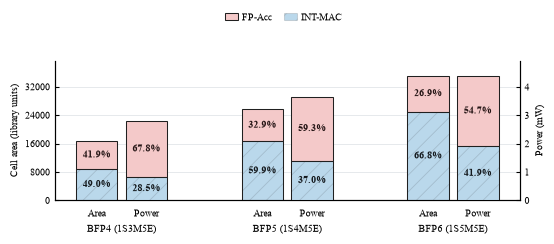

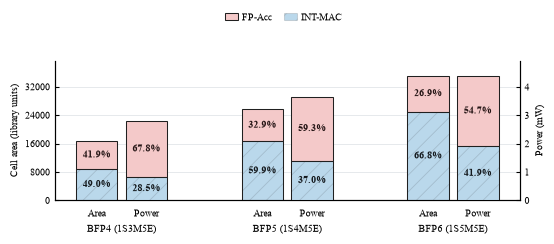

In [6]:
output_dir = Path("figures")
output_dir.mkdir(exist_ok=True)

# Two hue families keep the shared x axis unambiguous: cool teals belong to the left
# area axis, warm ambers to the right power axis. Within each family the dark tone
# marks FP-Acc, so the dominant share stays legible in grayscale printing.
palettes = {
    "area": {"FP-Acc": "#1F5F6B", "INT-MAC": "#BCDCE1", "edge": "#0E3B44", "accent": "#17505B"},
    "power": {"FP-Acc": "#B5761F", "INT-MAC": "#F4DFB6", "edge": "#6B430C", "accent": "#96601A"},
}
text_color = "#232323"
grid_color = "#DDE3E9"
stack_components = ["INT-MAC", "FP-Acc"]
group_positions = np.arange(len(formats), dtype=float)
bar_width = 0.34
group_offset = 0.19

# One axes with twin scales: the formats are compared once, not twice.
fig, axis_area = plt.subplots(figsize=(3.50, 1.75))
fig.subplots_adjust(left=0.150, right=0.855, top=0.970, bottom=0.165)
axis_power = axis_area.twinx()

series_specs = [
    {
        "key": "area", "axis": axis_area, "source": area, "totals": area_totals.to_numpy(),
        "scale": 1.0e3, "offset": -group_offset, "ylabel": "Cell area (10\u00b3 \u00b5m\u00b2)",
    },
    {
        "key": "power", "axis": axis_power, "source": power, "totals": power_totals.to_numpy(),
        "scale": 1.0, "offset": group_offset, "ylabel": "Power (mW)",
    },
]

for spec in series_specs:
    axis = spec["axis"]
    palette = palettes[spec["key"]]
    scale = spec["scale"]
    bottom = np.zeros(len(formats))
    for component in stack_components:
        values = spec["source"][component].to_numpy() / scale
        bars = axis.bar(
            group_positions + spec["offset"], values, width=bar_width, bottom=bottom,
            color=palette[component], edgecolor=palette["edge"], linewidth=0.70, zorder=3,
        )
        axis.bar_label(
            bars,
            labels=[f"{100.0 * value * scale / total:.0f}%" for value, total in zip(values, spec["totals"])],
            label_type="center", fontsize=5.0, zorder=5,
            color="#FFFFFF" if component == "FP-Acc" else palette["edge"],
        )
        bottom += values

    axis.set_ylabel(spec["ylabel"], color=palette["accent"], labelpad=3)
    axis.set_ylim(0, float(bottom.max()) * 1.04)
    axis.yaxis.set_major_locator(MaxNLocator(nbins=5, steps=[1, 2, 5, 10], min_n_ticks=4))
    axis.spines["top"].set_visible(False)
    axis.tick_params(axis="y", direction="out", colors=palette["accent"], length=2.5, width=0.7, pad=2.0)

axis_area.spines["left"].set_color(palettes["area"]["accent"])
axis_area.spines["right"].set_color(palettes["power"]["accent"])
axis_area.spines["bottom"].set_color(text_color)
axis_power.spines["left"].set_color(palettes["area"]["accent"])
axis_power.spines["right"].set_color(palettes["power"]["accent"])
axis_area.grid(axis="y", color=grid_color, linewidth=0.5, linestyle="-", zorder=0)
axis_area.set_axisbelow(True)
axis_area.set_xticks(group_positions)
axis_area.set_xticklabels([data_format.split()[0] for data_format in formats])
axis_area.set_xlim(group_positions[0] - 0.50, group_positions[-1] + 0.50)
axis_area.tick_params(axis="x", length=0, pad=3.0, labelcolor=text_color)

# Pairing both hues per row keeps the key to two lines; the swatch order matches the
# order named in the label, so one line covers the component and both scales.
legend_handles = [
    tuple(
        Patch(facecolor=palettes[key][component], edgecolor=palettes[key]["edge"], linewidth=0.70)
        for key in ("area", "power")
    )
    for component in ("FP-Acc", "INT-MAC")
]
axis_power.legend(
    legend_handles, ["FP-Acc (Area / Power)", "INT-MAC (Area / Power)"],
    handler_map={tuple: HandlerTuple(ndivide=None, pad=0.25)},
    loc="upper left", bbox_to_anchor=(0.005, 0.995), frameon=False,
    handlelength=2.30, handleheight=0.85, handletextpad=0.45, labelspacing=0.32,
    borderaxespad=0.0, labelcolor=text_color,
)

png_path = output_dir / "baseline_bfp_pe_component_power_area.png"
pdf_path = output_dir / "baseline_bfp_pe_component_power_area.pdf"
fig.savefig(png_path, dpi=1200, bbox_inches="tight", pad_inches=0.02)
fig.savefig(pdf_path, bbox_inches="tight", pad_inches=0.02)
print(f"Saved: {png_path.resolve()}")
print(f"Saved: {pdf_path.resolve()}")
fig